In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision as vision

import matplotlib.pyplot as plt

import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import *

# print(f"Torch: version {torch.__version__}")
# device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device("cpu")
# print(f"Device: {device}")
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [10]:
# Input and Outputs
# Input: 244 * 244 * 3 
# output: classification

# torchvision.datasets example datasa
# torchvision.models example and standard vision models

# torch.utils.data.Dataset : dataset class for custom datasets

In [11]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.7.1
0.22.1


In [12]:
# getting the data
# MORE: lets try to use EMNIST to find digits
import kagglehub as kg
print(kg.__version__)

# Download latest version
path = kg.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

# We are going to use fashion

0.3.12
Path to dataset files: /Users/giovannirasera/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


In [13]:
# Setting training data
train_data = datasets.FashionMNIST(
    root="dataFashion",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None # How to transform the labels,
)
test_data = datasets.FashionMNIST(
    root="dataFashion",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None 
)

In [14]:
len(train_data), len(test_data)

(60000, 10000)

In [15]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [16]:
print(image.shape) # we are using color channel first
print(label)
print(train_data.class_to_idx)
train_data.targets
class_names = train_data.classes
print(class_names)

torch.Size([1, 28, 28])
9
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

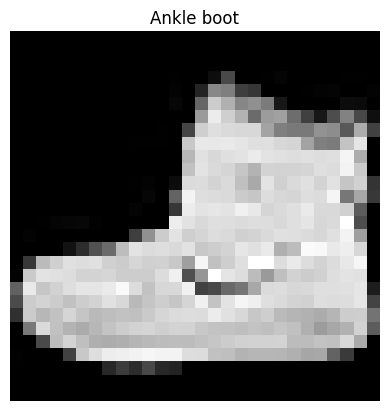

In [17]:
# plt.imshow(image) cannot use this because plt uses color channel last

plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

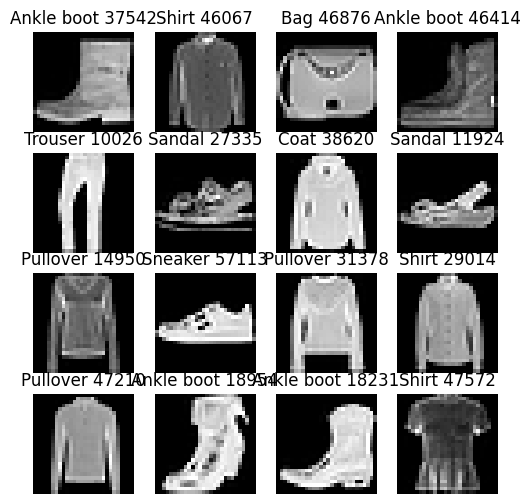

In [18]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(6, 6))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i) # i is the index
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label] + f" {random_idx}")
    plt.axis(False)


In [19]:
# Prepare dataloader
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: dataFashion
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: dataFashion
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [20]:
# DataLoader is trasforming data into a iterable and into batches
# Hardware cannot store all images into ram so we need to device the data

from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)
print(train_dataloader)
# print(test_dataloader)

In [21]:
print(f"Len of trian data: {len(train_dataloader)} of batchsize: {BATCH_SIZE}")

Len of trian data: 1875 of batchsize: 32


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

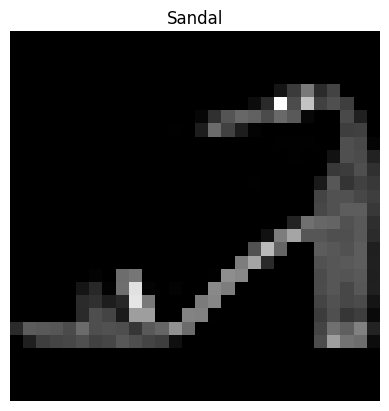

In [22]:
# whats inside training dataloader
train_features_batch, train_label_batch = next(iter(train_dataloader))
test_features_batch, test_label_betch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_label_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)


In [23]:
# Crate a baseline model
# to pass from conv to a nn we need to use Flatten
x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [24]:
flatted = nn.Flatten()(x)
flatted # One bit vector of features

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
         0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.2863, 0.0000, 0.0

In [36]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV0(inf, 10, len(class_names))

In [37]:
model.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [38]:
dummy_x = torch.rand([ 1, 28, 28])
model(dummy_x).shape

torch.Size([1, 10])

In [39]:
model.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0034, -0.0353,  0.0323,  ..., -0.0218, -0.0176,  0.0069],
                      [ 0.0097,  0.0137,  0.0196,  ..., -0.0238,  0.0124, -0.0214],
                      [-0.0112, -0.0170, -0.0243,  ...,  0.0066, -0.0149, -0.0091],
                      ...,
                      [-0.0231,  0.0100,  0.0303,  ...,  0.0048, -0.0134, -0.0141],
                      [-0.0112,  0.0124,  0.0062,  ...,  0.0035, -0.0279,  0.0321],
                      [ 0.0080,  0.0258,  0.0155,  ..., -0.0284, -0.0354, -0.0013]])),
             ('layer_stack.1.bias',
              tensor([ 0.0105, -0.0211,  0.0281,  0.0169,  0.0215,  0.0165, -0.0344, -0.0065,
                       0.0186,  0.0177])),
             ('layer_stack.2.weight',
              tensor([[-0.2877, -0.1792,  0.2305, -0.2618,  0.2397, -0.0610,  0.0232,  0.1542,
                        0.0851, -0.2027],
                      [ 0.1030, -0.2715, -0.1596, -0.0555, -0.0633,  0.2302, -0.

In [40]:
# Setting up optimizer and loss functions
# Multiflass data will be use crossentropyloss
# Optimizer: SGD
# Evaluation metrics will be accuracy

def flatten(y_, n_classes):
    y_train_blob = torch.zeros(len(y_))
    for i in range(len(y_train_blob)):
        for c in range(n_classes):
            if int(y_[i][c].item()) == 1:
                y_train_blob[i] = c
    return y_train_blob

# Calculate accuracy - out of 100 what percent the model gets right
def accuracy_fn(y_test, preds, n_classes = 4):
    y_test_blob = flatten(y_test, n_classes)
    peds_train_blob = flatten(preds, n_classes)
    correct = torch.sum(torch.eq(y_test_blob, peds_train_blob).type(torch.int))
    return  correct.item() / len(y_test) * 100


class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV0(inf, 16, len(class_names))

loss_fn = nn.MultiLabelSoftMarginLoss() 

optimizer = optim.SGD(
    params=model.parameters(),
    lr = 0.1
)

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def expand(y_blob, n_samples, num_classes):
    y = torch.zeros(n_samples, num_classes)
    for i in range(len(y_blob)):
        y[i][int(y_blob[i].item())] = 1
    return y

# # Training on batches
from tqdm.auto import tqdm # Progress bar
torch.manual_seed(42)
start = timer()
epochs = 5
for ep in tqdm(range(epochs)):
    print(f"Epoch: {ep} | ")
    train_loss = 0

    for batch, (X, y_b) in enumerate(train_dataloader):
        model.train()
        y = expand(y_b, len(y_b), len(class_names))

        # Logits
        y_logits = model(X).squeeze()
        # Using sigmoid activation and rounding
        y_pred = torch.round(torch.sigmoid(y_logits))
        # loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss # adding up loss per batch
        acc = accuracy_fn(y, y_pred, len(class_names))

        # Zero Grad
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # This is doint once per batch
        optimizer.step()

    # Device train loass
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    print(f"TrainLoss: {train_loss}, TestLoss: {test_loss}, TestAcc: {test_acc}")    

end = timer()

print_train_time(start, end, "cpu")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | 
TrainLoss: 0.16965632140636444, TestLoss: 0.12429114431142807, TestAcc: 64.96605431309904
Epoch: 1 | 
TrainLoss: 0.11093589663505554, TestLoss: 0.1071908101439476, TestAcc: 71.35583067092652
Epoch: 2 | 
TrainLoss: 0.0988951027393341, TestLoss: 0.09937448799610138, TestAcc: 74.38099041533546
Epoch: 3 | 
TrainLoss: 0.09346028417348862, TestLoss: 0.09584150463342667, TestAcc: 74.6305910543131
Epoch: 4 | 
TrainLoss: 0.09043638408184052, TestLoss: 0.09404467791318893, TestAcc: 75.66892971246007
Train time on cpu: 48.604 seconds


In [41]:
from helper_functions import accuracy_fn as not_my_acc_fn

torch.manual_seed(42)
def eval_model(model, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, acc_fn):
    loss, acc = 0, 0
    model.eval()
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    return {"model_name" : model.__class__.__name__,
        "model_loss": test_loss.item(), "model_acc": test_acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(
    model=model, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.09408218413591385,
 'model_acc': 75.63897763578275}

# Non Linear Model

In [43]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV1(inf, 16, len(class_names))

loss_fn = nn.MultiLabelSoftMarginLoss() 

optimizer = optim.SGD(
    params=model.parameters(),
    lr = 0.1
)

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def expand(y_blob, n_samples, num_classes):
    y = torch.zeros(n_samples, num_classes)
    for i in range(len(y_blob)):
        y[i][int(y_blob[i].item())] = 1
    return y

# # Training on batches
from tqdm.auto import tqdm # Progress bar
torch.manual_seed(42)
start = timer()
epochs = 1
for ep in tqdm(range(epochs)):
    print(f"Epoch: {ep} | ")
    train_loss = 0

    for batch, (X, y_b) in enumerate(train_dataloader):
        model.train()
        y = expand(y_b, len(y_b), len(class_names))

        # Logits
        y_logits = model(X).squeeze()
        # Using sigmoid activation and rounding
        y_pred = torch.round(torch.sigmoid(y_logits))
        # loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss # adding up loss per batch
        acc = accuracy_fn(y, y_pred, len(class_names))

        # Zero Grad
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # This is doint once per batch
        optimizer.step()

    # Device train loass
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    print(f"TrainLoss: {train_loss}, TestLoss: {test_loss}, TestAcc: {test_acc}")    

end = timer()

print_train_time(start, end, "cpu")

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 0 | 
TrainLoss: 0.6925469636917114, TestLoss: 0.6913942694664001, TestAcc: 15.914536741214057
Train time on cpu: 10.171 seconds


In [44]:
def train_model(model: nn.Module, loss_fn, optimizer, train_dataloader, epochs, accuracy_fn):
    # # Training on batches
    from tqdm.auto import tqdm # Progress bar
    torch.manual_seed(42)
    start = timer()
    for ep in tqdm(range(epochs)):
        train_loss = 0
        train_acc = 0
        model.train()
        for batch, (X, y) in enumerate(train_dataloader):
            # Logits
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            train_loss += loss
            acc = accuracy_fn(y, y_pred=y_pred.argmax(dim=1))
            train_acc += acc

            # Zero Grad
            optimizer.zero_grad()
            # backpropagation
            loss.backward()
            # This is doint once per batch
            optimizer.step()

        # Device train loass
        train_acc /= len(train_dataloader)
        train_loss /= len(train_dataloader)

        print(f"Epoch: {ep} | TrainLoss: {train_loss}, TrainAcc : {train_acc}")    

    end = timer()
    return model

def eval_model(model, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, acc_fn):
    loss, acc = 0, 0
    model.eval()
    test_loss = 0.0
    test_acc = 0
    len_l = len(data_loader)
    preds = []
    with torch.inference_mode():
        for X_test, y_test in data_loader:
            test_pred = model(X_test)
            preds.append(test_pred.argmax(dim=1))
            loss = loss_fn(test_pred, y_test)
            test_loss += loss
            acc = acc_fn(y_test, test_pred.argmax(dim=1))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    return {"model_name" : model.__class__.__name__,
        "model_loss": test_loss.item(), "model_acc": test_acc, "preds": preds}

# Calculate model 0 results on test dataset

class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV2(inf, 32, len(class_names))
loss_fn = nn.CrossEntropyLoss() 

optimizer = optim.SGD(
    params=model.parameters(),
    lr = 0.1
)
# Train
my_trained = train_model(model, loss_fn, optimizer, train_dataloader, 1, not_my_acc_fn)


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 0.6054062247276306, TrainAcc : 77.92666666666666


0.0


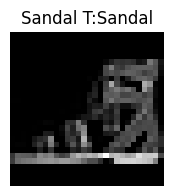

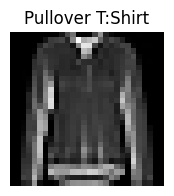

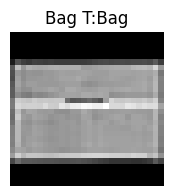

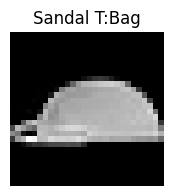

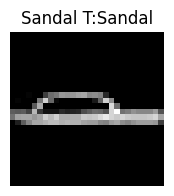

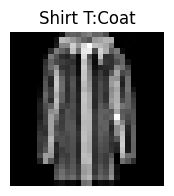

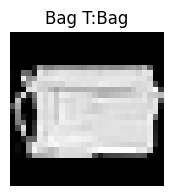

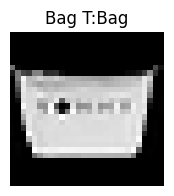

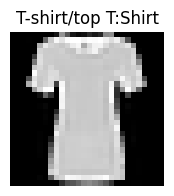

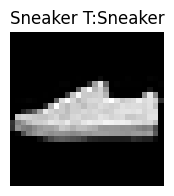

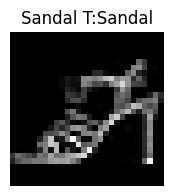

In [45]:
def print_img(model, data_loader):
    index = 0
    acc_sum = 0
    for X, l in data_loader:
        img = X
        pred = model(X)
        pred = pred.argmax(dim=1)
        label = pred[0]
        #Plot more images
        torch.manual_seed(42)
        fig = plt.figure(figsize=(2, 2))
        #random_idx = torch.randint(0, , size=[1]).item()
        plt.imshow(img[0].squeeze(), cmap="gray")
        plt.title(f"{class_names[label]} T:{class_names[l[0]]}")
        plt.axis(False)
        index+=1
        if index > 10:
            break
    print(acc_sum / len(data_loader))

# Test
model_0_results = eval_model(
    model=my_trained, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)

# Printing
print_img(my_trained, test_dataloader)

In [51]:
class FashionMNISTModelCNN(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model_cnn = FashionMNISTModelCNN(inf, 32, len(class_names))
loss_fn = nn.CrossEntropyLoss() 

optimizer = optim.SGD(
    params=model_cnn.parameters(),
    lr = 0.1
)
# Train
my_trained_cnn = train_model(model_cnn, loss_fn, optimizer, train_dataloader, 20, not_my_acc_fn)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 0.5933540463447571, TrainAcc : 77.97666666666667
Epoch: 1 | TrainLoss: 0.40101638436317444, TrainAcc : 85.47333333333333
Epoch: 2 | TrainLoss: 0.36181876063346863, TrainAcc : 86.95666666666666
Epoch: 3 | TrainLoss: 0.34329769015312195, TrainAcc : 87.54
Epoch: 4 | TrainLoss: 0.32847878336906433, TrainAcc : 88.195
Epoch: 5 | TrainLoss: 0.31912553310394287, TrainAcc : 88.415
Epoch: 6 | TrainLoss: 0.311601459980011, TrainAcc : 88.54
Epoch: 7 | TrainLoss: 0.30590736865997314, TrainAcc : 88.81833333333333
Epoch: 8 | TrainLoss: 0.29774782061576843, TrainAcc : 89.08666666666667
Epoch: 9 | TrainLoss: 0.29454776644706726, TrainAcc : 89.26833333333333
Epoch: 10 | TrainLoss: 0.29124876856803894, TrainAcc : 89.38333333333334
Epoch: 11 | TrainLoss: 0.2889615297317505, TrainAcc : 89.52333333333333
Epoch: 12 | TrainLoss: 0.2853791415691376, TrainAcc : 89.6
Epoch: 13 | TrainLoss: 0.28356295824050903, TrainAcc : 89.59
Epoch: 14 | TrainLoss: 0.2795639634132385, TrainAcc : 89.8116666

{'model_name': 'FashionMNISTModelCNN', 'model_loss': 0.3659333884716034, 'model_acc': 87.21046325878594, 'preds': [tensor([3, 9, 9, 7, 3, 2, 8, 0, 4, 1, 7, 8, 2, 8, 7, 9, 3, 2, 7, 8, 9, 5, 1, 8,
        3, 3, 4, 2, 1, 9, 5, 7]), tensor([2, 3, 9, 9, 4, 0, 3, 2, 0, 5, 2, 7, 4, 1, 8, 9, 3, 6, 2, 1, 9, 5, 7, 7,
        0, 4, 5, 3, 1, 4, 0, 7]), tensor([3, 4, 0, 4, 3, 5, 7, 2, 9, 6, 2, 6, 7, 1, 1, 1, 7, 2, 7, 7, 7, 9, 7, 1,
        7, 7, 7, 9, 0, 2, 1, 7]), tensor([6, 0, 4, 3, 5, 9, 5, 0, 3, 3, 8, 1, 1, 7, 1, 2, 8, 7, 5, 4, 1, 7, 0, 6,
        1, 9, 9, 3, 9, 9, 2, 6]), tensor([1, 9, 2, 1, 6, 3, 6, 5, 5, 6, 6, 5, 5, 8, 4, 2, 2, 9, 3, 5, 2, 3, 2, 4,
        8, 1, 3, 9, 2, 3, 7, 9]), tensor([1, 7, 5, 7, 0, 2, 3, 5, 2, 5, 7, 7, 9, 1, 7, 6, 2, 9, 4, 1, 7, 3, 0, 9,
        0, 1, 6, 1, 9, 0, 7, 2]), tensor([1, 0, 7, 9, 8, 5, 5, 0, 3, 2, 3, 3, 9, 6, 1, 2, 5, 8, 8, 3, 7, 6, 6, 7,
        8, 9, 6, 2, 1, 2, 8, 1]), tensor([2, 2, 8, 8, 8, 5, 8, 9, 1, 7, 3, 4, 9, 4, 6, 6, 2, 5, 6, 5, 5, 4, 6, 4,
       

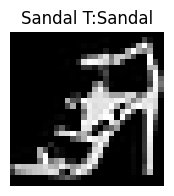

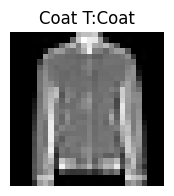

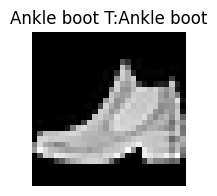

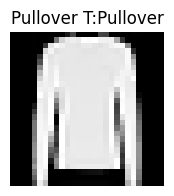

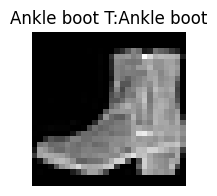

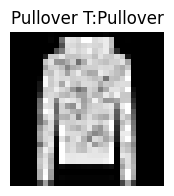

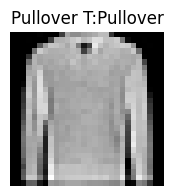

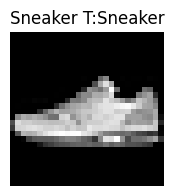

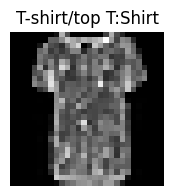

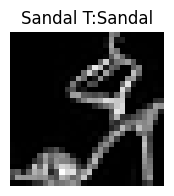

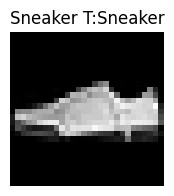

In [ ]:
# Test
model_cnn = eval_model(
    model=my_trained_cnn, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
print(model_cnn)

# Printing
print_img(my_trained_cnn, test_dataloader)